# **MÓDULO 21 - Projeto de Credit Score - Árvore de Decisão**


No módulo 17, vocês realizaram a primeira etapa do projeto de crédito de vocês. Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste. Já no módulo 14, aplicaram a base já tratada o algoritmo de Naive Bayes, onde avaliaram os resultados das previsões. Nesse módulo aplicaremos a nossa base o algoritmo da árvore de decisão.

In [122]:
import pandas as pd
import numpy as np
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import accuracy_score

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [123]:
X_train = pd.read_csv('./data/X_train.csv', delimiter=',')
X_test = pd.read_csv('./data/X_test.csv', delimiter=',')
y_train = pd.read_csv('./data/y_train.csv', delimiter=',')
y_test  = pd.read_csv('./data/y_test.csv', delimiter=',')

In [124]:
X_train

,customerid,genero,idoso,casado,dependents,tempo_como_cliente,phoneservice,servico_internet,servico_seguranca,suporte_tecnico,streamingtv,tipo_contrato,paymentmethod,pagamento_mensal,total_pago
0,1386,2,0,1,1,8,1,3,2,0,0,0,3,65.607563,482.25
1,1146,2,1,0,0,17,2,3,0,0,0,0,2,45.050000,770.60
2,537,2,1,1,0,71,2,1,0,0,2,2,2,99.200000,7213.75
3,182,2,0,1,1,4,1,2,1,1,1,2,3,19.900000,76.65
4,2186,2,1,1,0,71,2,1,2,2,0,1,2,92.000000,6585.20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1861,722,2,0,0,0,1,1,1,0,0,0,0,3,85.800000,85.80
1862,232,2,0,1,0,69,2,2,1,1,1,2,0,24.250000,1641.80
1863,569,2,1,1,1,11,2,1,0,0,0,0,1,75.200000,775.30
1864,49,2,0,0,0,70,2,1,2,2,2,1,1,115.550000,8127.60


In [125]:
X_test

,customerid,genero,idoso,casado,dependents,tempo_como_cliente,phoneservice,servico_internet,servico_seguranca,suporte_tecnico,streamingtv,tipo_contrato,paymentmethod,pagamento_mensal,total_pago
0,2476,2,0,1,0,38,2,1,2,0,0,0,2,79.45,3013.05
1,1804,2,1,0,0,1,2,1,0,0,0,0,2,69.25,69.25
2,221,2,0,0,0,3,1,1,0,0,0,0,2,75.25,242.00
3,1842,2,0,1,0,27,1,3,2,2,2,1,3,80.85,2204.35
4,661,2,0,1,1,23,1,2,1,1,1,2,3,25.10,611.45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
617,544,2,0,0,0,26,2,3,0,2,2,0,1,44.45,1183.80
618,1661,2,0,0,0,1,1,3,0,0,0,0,0,43.85,43.85
619,1037,2,0,0,1,21,1,3,2,0,0,1,3,64.85,1336.80
620,647,2,0,0,0,21,2,3,0,2,0,0,3,36.00,780.15


In [126]:
y_train

,churn
0,0
1,1
2,0
3,0
4,0
...,...
1861,1
1862,0
1863,0
1864,1


In [127]:
y_test

,churn
0,1
1,1
2,1
3,0
4,0
...,...
617,0
618,0
619,0
620,0


In [128]:
y_train.value_counts()

churn
0        1376
1         490
Name: count, dtype: int64

In [129]:
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# 2) Explique com suas palavras, qual o passo a passo para a aplicação do algoritmo da árvore de decisão, não esqueça de citar a etapa de avaliação do modelo e também como podemos melhorar nosso modelo.

Primeiro devemos entender qual e o problema e qual e o que queremos prever, quais metricas sao importantes e qual erro tem maior peso. Entao comecaremos  com a coleta, seguindo por tratamento de dados e depois analise exploratoria de dados. Apos essas etapas dividiremos em treino e teste para verificar se o nosso modelo realmente aprende com padroes e apenas memoriza dados. Feito o treino e teste muito provavelmente eles estaram desbalanceados, por isso e necessario balancear esses dados pois teremos um aprendizado impreciso que no final nos retornaram metricas que nos levaram a escolhas erradas levando assim a grande perdas ne negocio. Enfim poderemos treinar nosso modelo, pode ser tanto para classificacao ou regressao, nesse caso que sao dados booleanos o indicado e  classificacao. Apos rodar o modelo podemos fazer fazer a visualizacao da arvore que muito provalvelmente sera extensa e com isso precisaremos escolher as features que mais nos importam. Validaremos e observaremos as metricas e tiraremos insights delas.

# 3) Aplique o algortimo da árvore de decisão aos dados de treinamento, utilizando critério de Gini e random state = 0.
Traga a acurácia para o modedlo com os dados de treino.

In [130]:
arvore_churn = DecisionTreeClassifier(criterion= 'gini', random_state=0, max_depth=3)
arvore_churn.fit(X_train_balanced, y_train_balanced)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [131]:
arvore_churn.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 0,
 'splitter': 'best'}

 # 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [132]:
pred_train = arvore_churn.predict(X_train_balanced)
pred_test = arvore_churn.predict(X_test)

print(f'{classification_report(y_train_balanced, pred_train)}\n\n\n{classification_report(y_test,pred_test)}')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1376
           1       1.00      1.00      1.00      1376

    accuracy                           1.00      2752
   macro avg       1.00      1.00      1.00      2752
weighted avg       1.00      1.00      1.00      2752



              precision    recall  f1-score   support

           0       0.85      0.76      0.80       465
           1       0.46      0.59      0.51       157

    accuracy                           0.72       622
   macro avg       0.65      0.67      0.66       622
weighted avg       0.75      0.72      0.73       622



Temos

Rodei o codigo uma primeira vez e meus dados de treino obtiveram overfitting, ele apenas memorizou os dados.
Optei por dimin

# 5) Plote a árvore de decisão.
É possível fazer uma avaliação visual? Qual a profundidade da árvore?

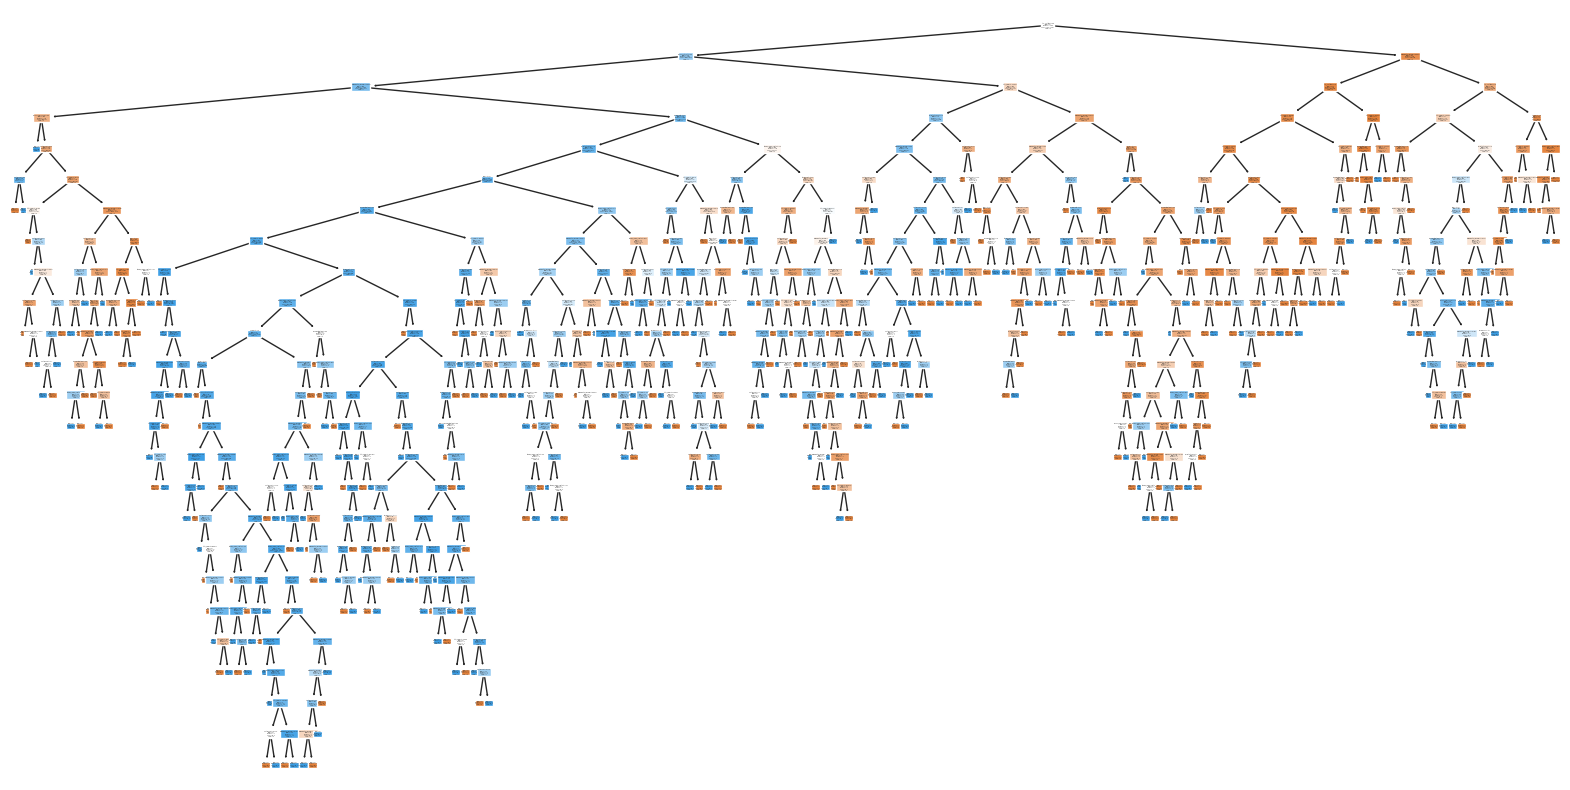

In [133]:
plt.figure(figsize=(20,10))
plot_tree(arvore_churn, filled=True, feature_names=X_train.columns, class_names=['0','1'])
plt.show()

Temos a presenca de muitos nos, isso pode indicar que temos muitas features desnecessarias.

# 6) Identifique as 2 principais features do modelo.


Text(0.5, 1.0, 'Importancia das features na arvore de decisao')

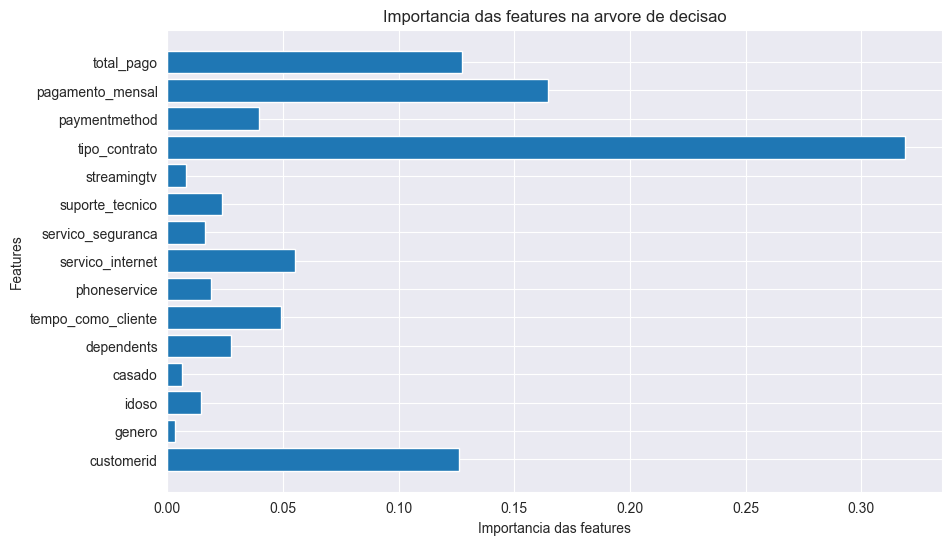

In [134]:
importancia_features = arvore_churn.feature_importances_

nomes_features = X_train.columns

plt.figure(figsize=(10,6))
plt.barh(nomes_features, importancia_features)
plt.xlabel('Importancia das features')
plt.ylabel('Features')
plt.title('Importancia das features na arvore de decisao')

# 7) Rode um modelo de árvore de decisão apenas com as 2 principais features encontradas. E avalie os resultados. Para você o desempenho da árvore está melhor que o modelo anterior? Justifique.

In [135]:
X_train_reduzido = X_train[['tipo_contrato','pagamento_mensal']]
X_test_reduzido = X_test[['tipo_contrato','pagamento_mensal']]

In [157]:
arvore_churn_reduzida = DecisionTreeClassifier(criterion='gini', random_state=0)
arvore_churn_reduzida.fit(X_train_reduzido, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [158]:
teste_reduzido = arvore_churn_reduzida.predict(X_test_reduzido)
train_reduzido = arvore_churn_reduzida.predict(X_train_reduzido)

In [159]:
print(f'{classification_report(y_test,teste_reduzido)}\n\n\n {classification_report(y_train ,train_reduzido)}')

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       465
           1       0.43      0.34      0.38       157

    accuracy                           0.72       622
   macro avg       0.61      0.59      0.60       622
weighted avg       0.70      0.72      0.71       622



               precision    recall  f1-score   support

           0       0.89      0.98      0.93      1376
           1       0.92      0.67      0.78       490

    accuracy                           0.90      1866
   macro avg       0.91      0.83      0.86      1866
weighted avg       0.90      0.90      0.89      1866



In [160]:
matriz_confusao = confusion_matrix(y_test, previsoes_reduzido)
matriz_confusao

array([[394,  71],
       [ 76,  81]])

[Text(0.6198817267291532, 0.98, 'tipo_contrato <= 0.5\ngini = 0.387\nsamples = 1866\nvalue = [1376.0, 490.0]\nclass = 0'),
 Text(0.32306985294117646, 0.94, 'pagamento_mensal <= 71.5\ngini = 0.49\nsamples = 1026\nvalue = [586, 440]\nclass = 0'),
 Text(0.4714757898351648, 0.96, 'True  '),
 Text(0.11744000484809308, 0.9, 'pagamento_mensal <= 30.5\ngini = 0.441\nsamples = 549\nvalue = [369, 180]\nclass = 0'),
 Text(0.039754363283775046, 0.86, 'pagamento_mensal <= 20.175\ngini = 0.297\nsamples = 138\nvalue = [113, 25]\nclass = 0'),
 Text(0.01809954751131222, 0.82, 'pagamento_mensal <= 19.225\ngini = 0.379\nsamples = 63\nvalue = [47, 16]\nclass = 0'),
 Text(0.009696186166774402, 0.78, 'pagamento_mensal <= 19.025\ngini = 0.198\nsamples = 9\nvalue = [8, 1]\nclass = 0'),
 Text(0.007110536522301228, 0.74, 'pagamento_mensal <= 18.925\ngini = 0.32\nsamples = 5\nvalue = [4, 1]\nclass = 0'),
 Text(0.004524886877828055, 0.7, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]\nclass = 0'),
 Text(0.0096961861667

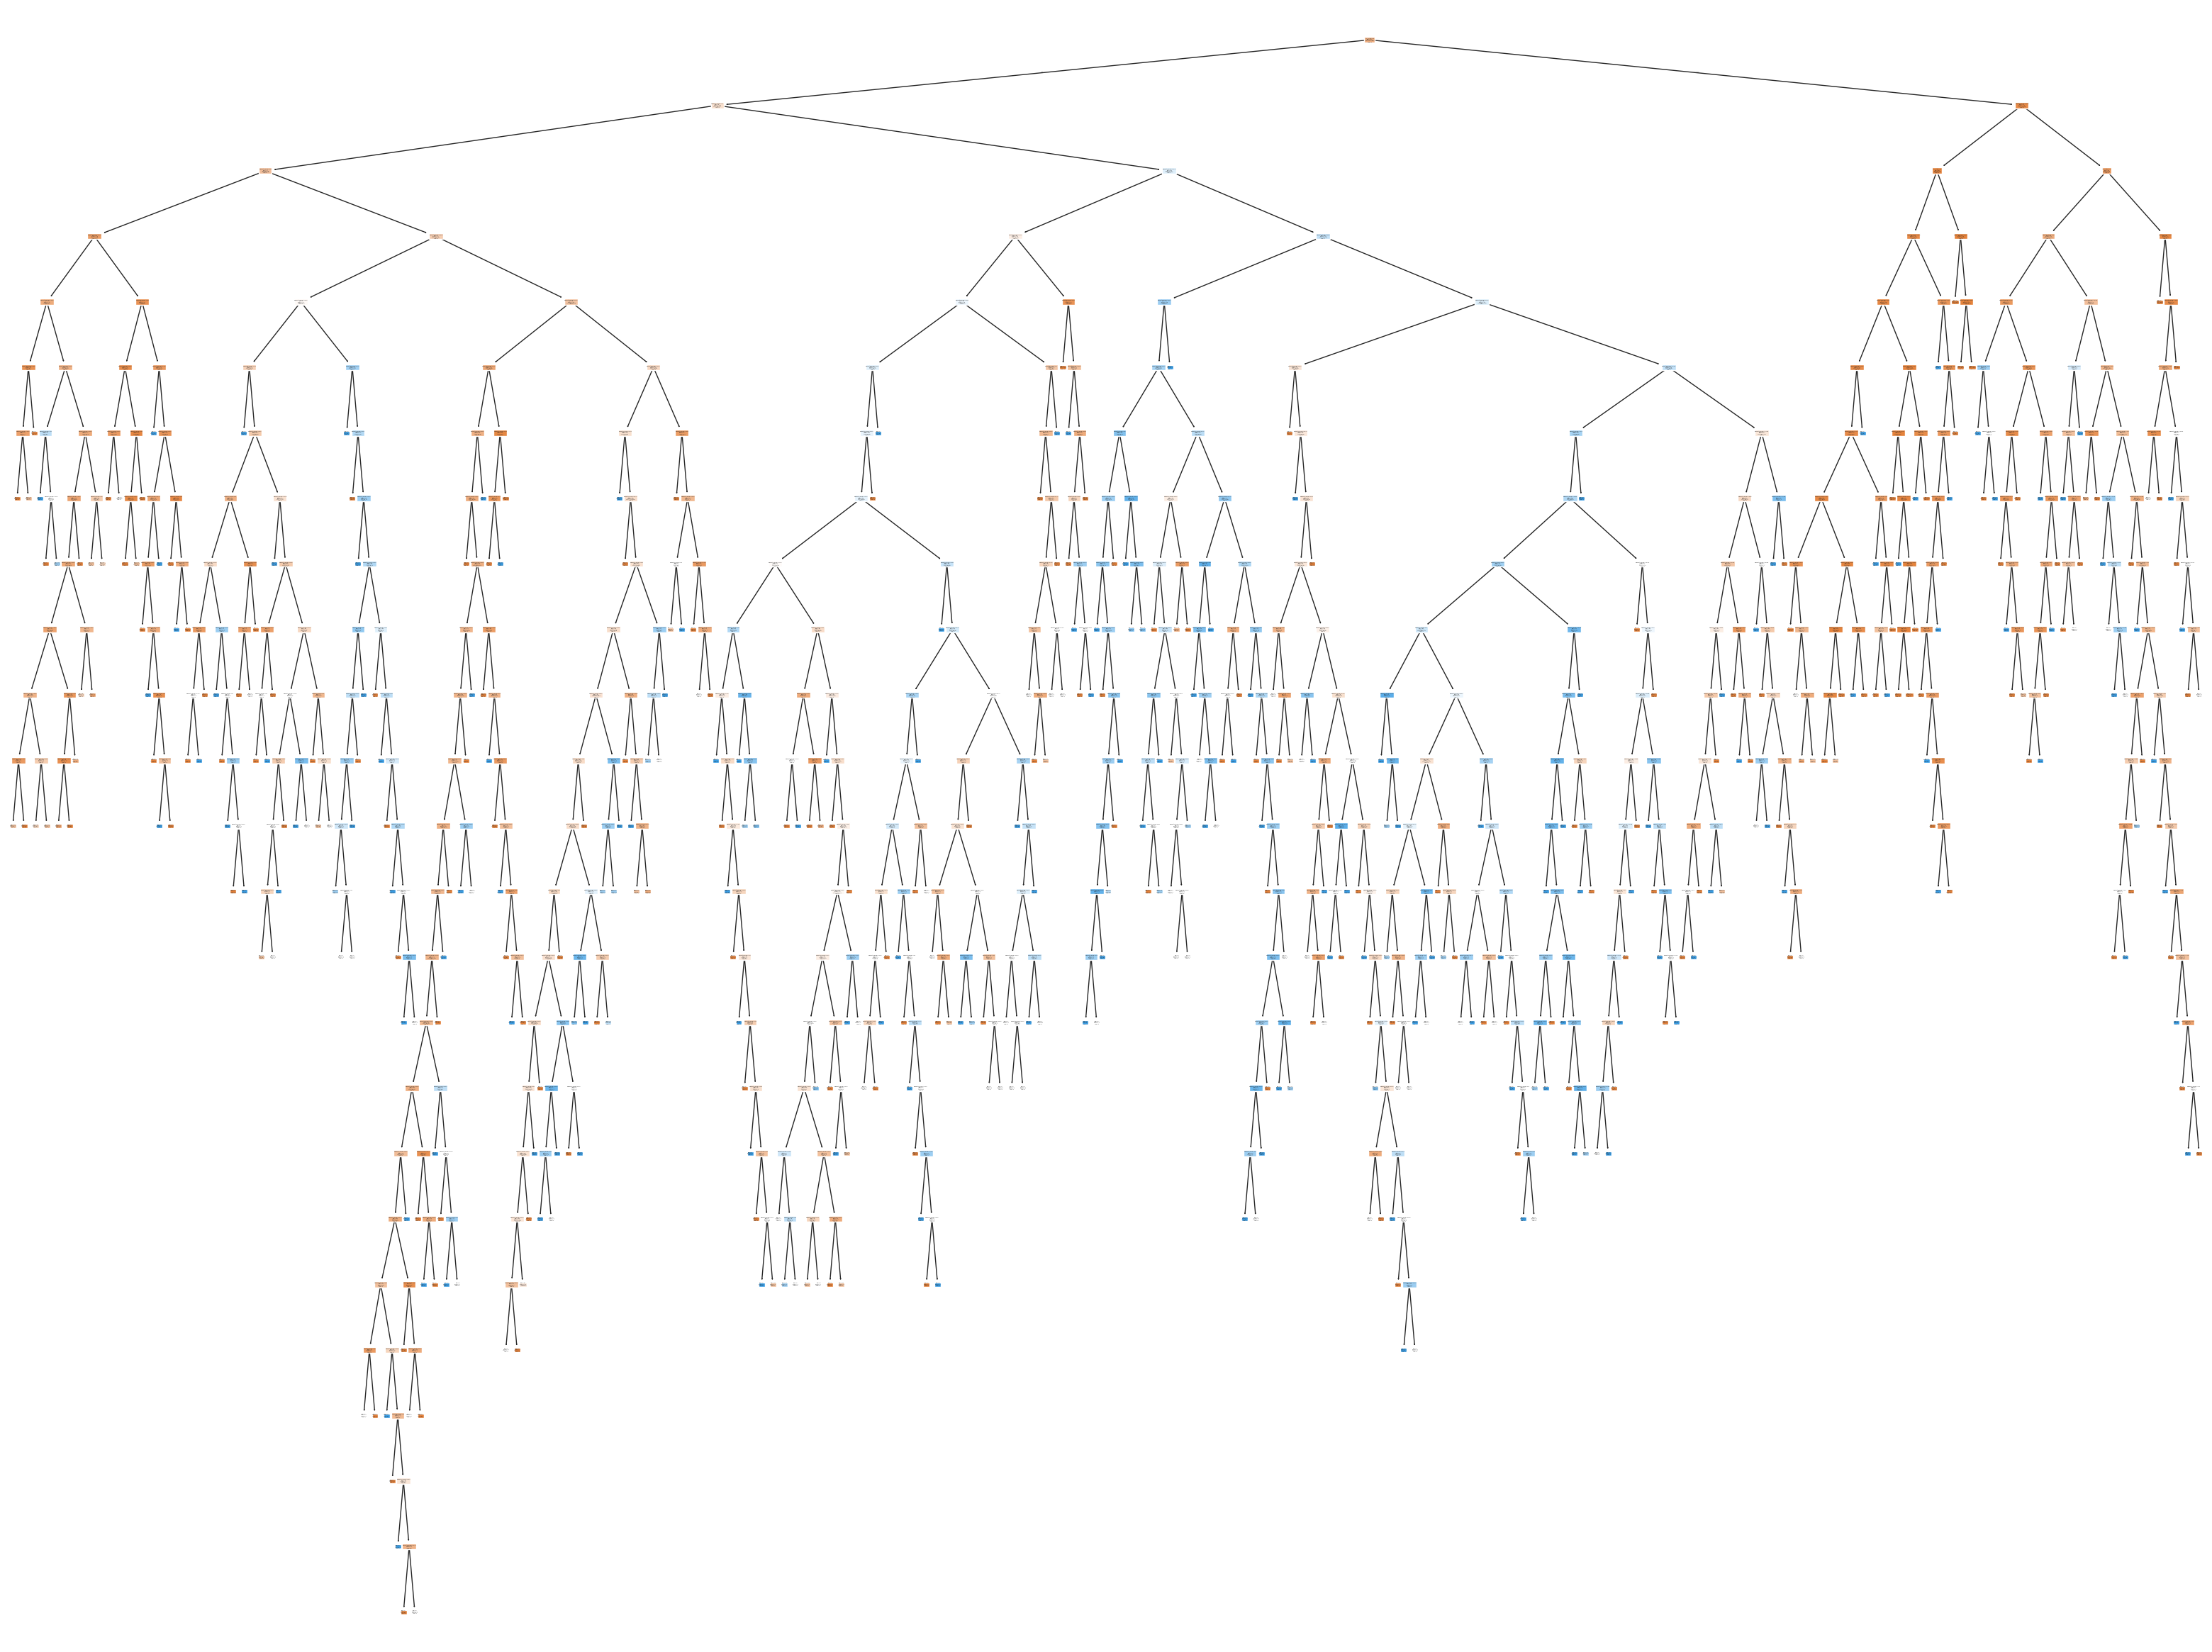

In [161]:
plt.figure(figsize=(40,30))
plot_tree(arvore_churn_reduzida, filled=True, feature_names=X_train_reduzido.columns, class_names=['0','1'])

# 8) Compare os resultados obtidos com a árvore de decisão com os resultados do Naive Bayes (Exercício módulo 20). Qual parece ter se adequado melhor aos dados e tem melhores resultados de avaliação? Justifique.

In [77]:
#Seu texto aqui

O modelo no final continuou com overfiting, talvez nao seja necessario reduzir as features, apenas limitar a profundidade da arvore de decisao. Ele ate consegue aprender bem no treino mas nao esta conseguindo generalizar bem. Tivemos um recall muito baixo na base de teste e ela e nosa metrica mais importante. Nesse caso eu continuaria com Naive bayes, ele demonstrou ter uma acuracia e recall superiores a esse modelo.